In [2]:
import os
import signal
import sys
import time

import example_robot_data
import numpy as np
import pinocchio as pin
import pinocchio.visualize

import crocoddyl

%load_ext line_profiler

In [3]:
WITHDISPLAY = "display"

# Loading the anymal model
a1 = example_robot_data.load("a1")
rmodel = a1.model

lims = rmodel.effortLimit
lims *= 0.5  # reduced artificially the torque limits
rmodel.effortLimit = lims

lfFoot, rfFoot, lhFoot, rhFoot = "FL_foot", "FR_foot", "RL_foot", "RR_foot"
lfCalf, rfCalf, lhCalf, rhCalf = "FL_calf", "FR_calf", "RL_calf", "RR_calf"
body = "trunk"

rdata = rmodel.createData()
state = crocoddyl.StateMultibody(rmodel)
actuation = crocoddyl.ActuationModelFloatingBase(state)
lf_id = rmodel.getFrameId(lfFoot)
rf_id = rmodel.getFrameId(rfFoot)
lh_id = rmodel.getFrameId(lhFoot)
rh_id = rmodel.getFrameId(rhFoot)
body_id = rmodel.getFrameId(body)
lfcalf_id = rmodel.getFrameId(lfCalf)
rfcalf_id = rmodel.getFrameId(rfCalf)
lhcalf_id = rmodel.getFrameId(lhCalf)
rhcalf_id = rmodel.getFrameId(rhCalf)

_integrator = 'euler'
_control = 'one'

# standing configurations
q0 = rmodel.referenceConfigurations["standing"]
rmodel.defaultState = np.concatenate([q0, np.zeros(rmodel.nv)])
x0 = rmodel.defaultState

In [5]:
display = crocoddyl.MeshcatDisplay(a1)
display.rate = -1
display.freq = 1
display.robot.viewer.jupyter_cell()


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7003/static/


In [ ]:
from tqdm import tqdm

from utils.costs import handstand, upright, crouch, add_lf_cost
from utils.models import ContactModel, IAM_shoot

# profiler, 看one shoot计算时间
def shootbench():
    costs_r,costs_t = upright(rmodel, state, actuation)
    DT, N = 2.5e-2, 20
    rho = 1 # 脚离地
    contact_ids = [lf_id, rf_id, lh_id, rh_id]
    friction = [0.8] * 4
    contact_model = ContactModel(state,contact_ids,friction)
    # 减少滑动
    add_lf_cost(costs_r,state,actuation,contact_ids)
    actionmodels = IAM_shoot(N,state, actuation, (costs_r,costs_t), contact_model, DT, rho)

    maxiter = 1
    is_feasible = False
    init_reg = 0.1

    problem = crocoddyl.ShootingProblem(x0, actionmodels[:-1], actionmodels[-1])
    solver = crocoddyl.SolverBoxFDDP(problem)

    xs = [x0] * (solver.problem.T + 1) # list of array即可
    us = solver.problem.quasiStatic([x0] * solver.problem.T)

    print('Initialization success !')
    solver.solve(xs, us, maxiter, is_feasible, init_reg)


# shootbench()

%lprun -T shootbench_profiler.txt -f DAM_contact.collision_test -f DAM_contact.calc -f DAM_contact.calcDiff -f ContactModel.auto_diff -f DAM_contact.solve_contact shootbench()


Initialization success !

*** Profile printout saved to text file 'shootbench_profiler_my.txt'. 


Timer unit: 1e-09 s

Total time: 0.0700967 s
File: /home/shaoqin/ccd/utils/models.py
Function: auto_diff at line 54

Line #      Hits         Time  Per Hit   % Time  Line Contents
    54                                                   
    55                                               @profile    
    56         1       1298.0   1298.0      0.0      def auto_diff(self):
    57         1        388.0    388.0      0.0          cmodel, cdata = self.cmodel, self.cdata
    58         1       1201.0   1201.0      0.0          qsym = self.qsym
    59         1        378.0    378.0      0.0          self.dJ_dq_funs = []
    60                                                   self.dh_dq_funs = []
    61         5       2663.0    532.6      0.0          
    62         4       5472.0   1368.0      0.0          for i in self.contact_ids:
    63                                                       def frameJacobian(q_sym):
    64                                                           q

In [ ]:
from tqdm import tqdm

from utils.costs import handstand, upright, crouch, add_lf_cost
from utils.models import ContactModel, IAM_shoot
from utils.cimpc import cimpc

# profiler, multi shoot计算时间
def mpcbench():
    costs_r,costs_t = upright(rmodel, state, actuation)

    DT, N = 2.5e-2, 20
    rho = 1 # 显著影响cost..., cost不收敛就要加大cost权重
    # actionmodels = IAM_ccd(N,state, actuation, costs, contacts, DT)
    contact_ids = [lf_id, rf_id, lh_id, rh_id,
                ]# , lfcalf_id, rfcalf_id, lhcalf_id, rhcalf_id]
    friction = [0.8] * 4
    contact_model = ContactModel(state,contact_ids,friction)
    add_lf_cost(costs_r,state,actuation,contact_ids)
    actionmodels = IAM_shoot(N,state, actuation, [costs_r,costs_t], contact_model, DT, rho)

    x_traj, u_traj = cimpc(0.5, x0, actionmodels)


# mpcbench()

%lprun -T profiler_mpc.txt -f DAM_contact.collision_test -f DAM_contact.calc -f DAM_contact.calcDiff -f ContactModel.auto_diff -f DAM_contact.solve_contact mpcbench()


Initialization success !
Initial cost: 21235.323936070057


  5%|▌         | 1/20 [00:00<00:07,  2.56it/s]

Step 1, cost: 13119.605860228436
Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "/home/shaoqin/miniconda3/envs/ccd/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_49873/383471178.py", line 33, in <module>
    get_ipython().run_line_magic('lprun', '-T profiler_mpc.txt -f DAM_contact.collision_test -f DAM_contact.calc -f DAM_contact.calcDiff -f ContactModel.auto_diff -f DAM_contact.solve_contact mpcbench()')
  File "/home/shaoqin/miniconda3/envs/ccd/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 2432, in run_line_magic
    result = fn(*args, **kwargs)
  File "/home/shaoqin/miniconda3/envs/ccd/lib/python3.9/site-packages/line_profiler/ipython_extension.py", line 130, in lprun
    profile.runctx(arg_str, global_ns, local_ns)
  File "/home/shaoqin/miniconda3/envs/ccd/lib/python3.9/site-packages/line_profiler/line_profiler.py", line 185, in runctx
    exec(cmd, globals, locals)
  File "<string>

In [ ]:
from utils.costs import target_cost
from utils.models import DAM_contact
import utils.cimpc
from utils.cimpc import walking, flip, spining


DT, N = 2.5e-2, 20
# rho = 0.01 # 大一点cost突然下降, 太大会倾向于滑动
rho = 0.01 # for x0+=0.55
rho = 0.01 # for v=0.5, 0.7
rho = 0.05 # for v=1
# rho = 0.1 # 直立走

contact_ids = [lf_id, rf_id, lh_id, rh_id] # + [body_id, lfcalf_id,rfcalf_id,lhcalf_id,rhcalf_id]
friction = [0.9] * 4 # + [100] + [0.9] * 4
contact_model = ContactModel(state,contact_ids,friction)
# add_lf_cost(costs_r,state,actuation,contact_ids)

action_component_wo_costs = [N, state, actuation, contact_model, DT, rho]

# 四足走
# v=1
# 直立走
# v=0.5
x_traj, u_traj = walking(5, action_component_wo_costs, v)

# 空翻
# x_traj, u_traj = flip(3, action_component_wo_costs)

# 托马斯
# v=0.3
# x_traj, u_traj = spining(2, action_component_wo_costs,v)

Initialization success !
Initial cost: 1.0586069923919663e-05


100%|██████████| 80/80 [00:26<00:00,  3.04it/s]

Step 80, cost: 178.35791932254216


In [192]:
# traj_cut = -20
traj_cut = -1
x_display = x_traj[:traj_cut]
dts = [DT] * len(x_display)
display.display(x_display, dts, [], [], [], [], [], dts, 1)

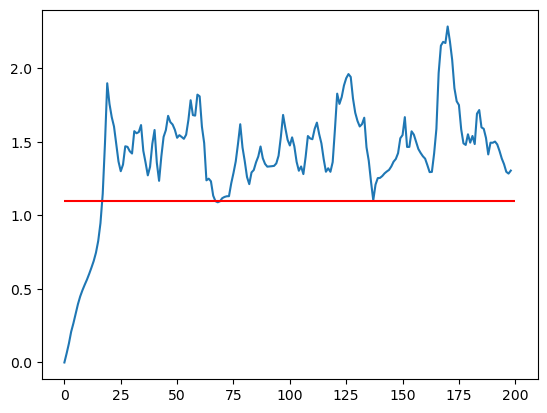

In [178]:
import matplotlib.pyplot as plt

# vx: tracking
plt.plot( (np.diff(np.array(x_display),axis=0)/2.5e-2)[:,0] )
plt.hlines(v+0.1,xmin=0,xmax=len(x_display),colors='r')
plt.show()

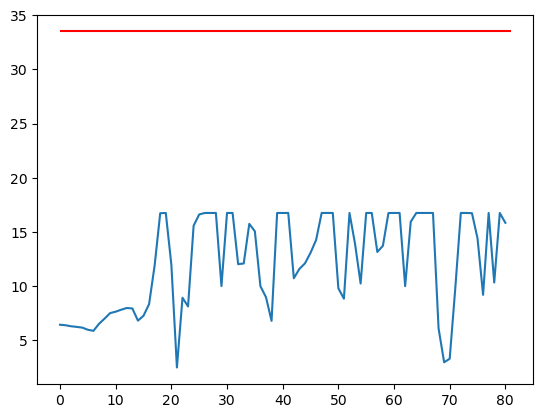

In [187]:
# torque limit
plt.plot( np.abs(np.array(u_traj)).max(axis=1) )
plt.hlines(33.5,xmin=0,xmax=len(u_traj),colors='r')
plt.show()